# 7. Ekstraksi Fitur TSFEL, Reduksi PCA, & K-Means Clustering

Dokumen ini menjelaskan alur lengkap pengolahan data polutan udara (**CO, $NO_2$, dan $SO_2$**) wilayah **Surabaya Selatan** (rentang waktu 31 Agustus 2025 s.d. 31 Agustus 2026), mulai dari eksplorasi deret waktu, ekstraksi 68 fitur TSFEL per polutan (total 204 kolom), reduksi dimensi menggunakan PCA, hingga analisis *K-Means Clustering* dan integrasi database Aiven Cloud.

---

## 1. Eksplorasi Data & Time Series Plot (Semua Polutan)

Sebelum melakukan ekstraksi fitur, kita melakukan visualisasi deret waktu (*time series plot*) untuk melihat tren harian dan karakteristik fluktuasi dari ketiga polutan secara bersamaan.

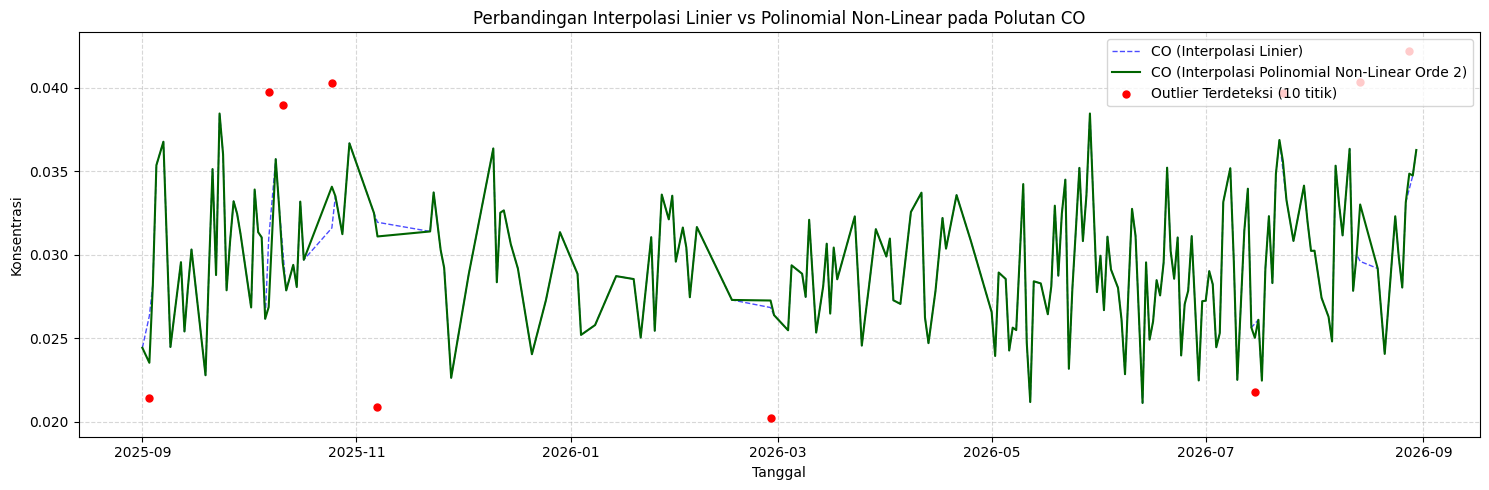

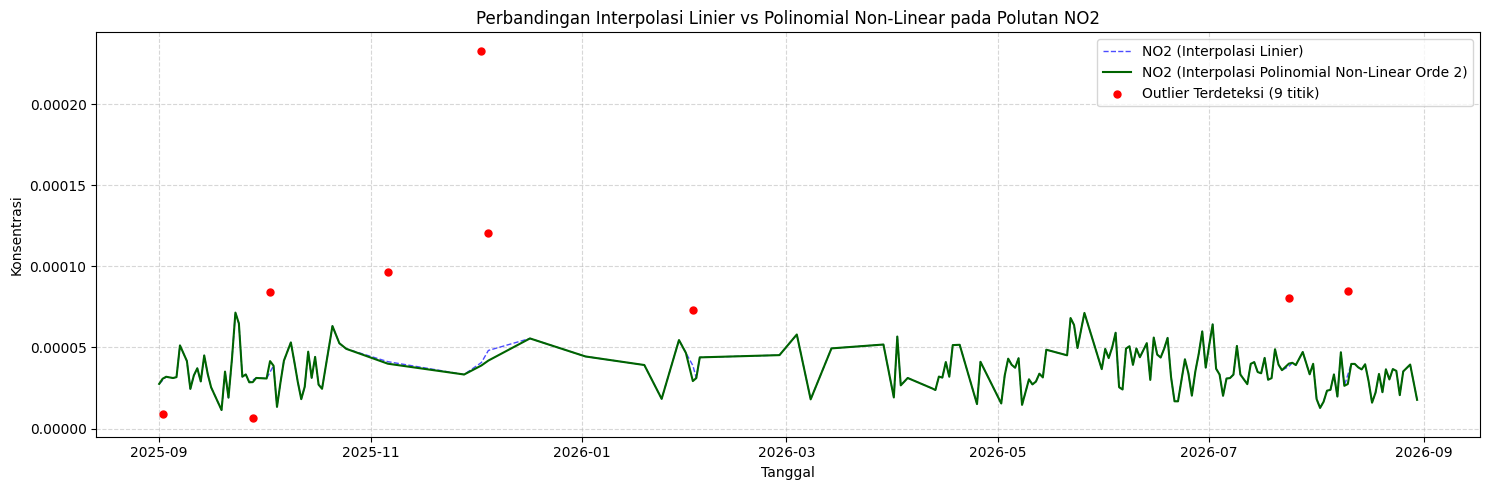

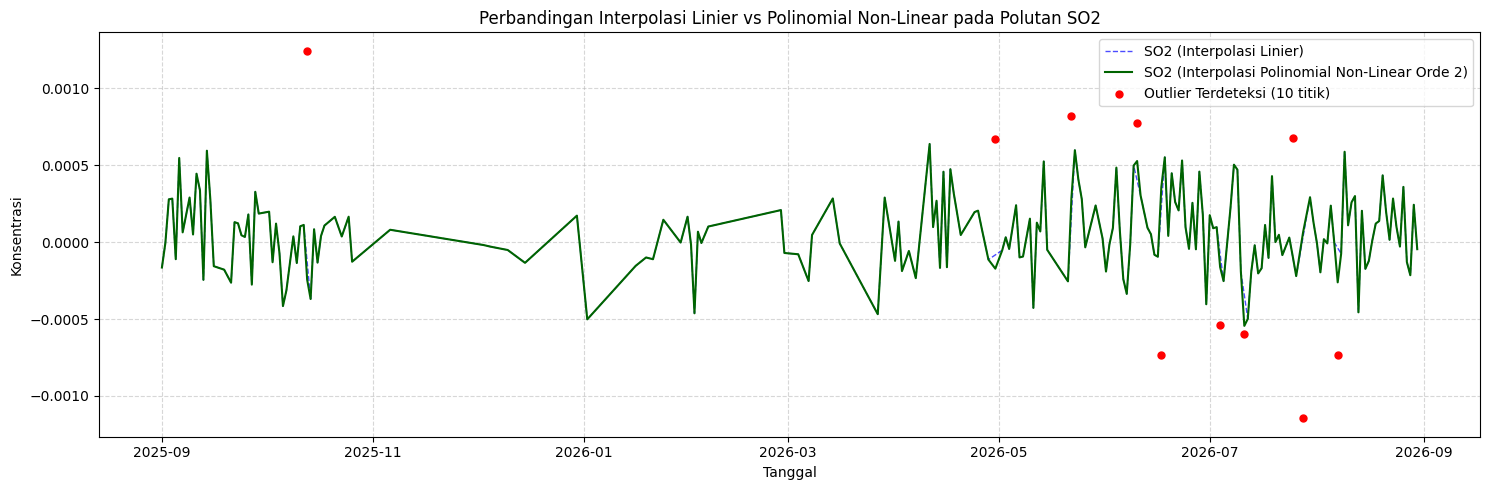

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

pollutants = ['CO', 'NO2', 'SO2']
CONTAMINATION = 0.05

for pol in pollutants:
    try:
        # 1. Load data
        df = pd.read_csv(f"data/processed/data_polutan_{pol.lower()}_clean.csv")
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)

        # Parse data numerik
        def parse_val(v):
            if pd.isna(v) or v is None: return np.nan
            s = str(v).replace('[', '').replace(']', '').strip()
            return float(s) if s.lower() not in ['none', 'nan', ''] else np.nan

        df[pol] = df[pol].apply(parse_val)
        df = df.dropna(subset=[pol]).copy()

        # 2. Deteksi Outlier dengan Isolation Forest
        model = IsolationForest(contamination=CONTAMINATION, random_state=42)
        df['anomaly'] = model.fit_predict(df[[pol]])  # -1 = outlier, 1 = normal

        # 3. Ganti Outlier jadi NaN
        df_base = df.copy()
        df_base.loc[df_base['anomaly'] == -1, pol] = np.nan

        # 4a. Interpolasi Linier
        df_linear = df_base.copy()
        df_linear[pol] = df_linear[pol].interpolate(method='linear').ffill().bfill()

        # 4b. Interpolasi Polinomial Non-Linear (Orde 2 / Quadratic)
        df_poly = df_base.copy()
        df_poly[pol] = df_poly[pol].interpolate(method='polynomial', order=2).ffill().bfill()

        # 5. Visualisasi Plot Perbandingan
        plt.figure(figsize=(15, 5))
        
        # Plot Linier
        plt.plot(df_linear['date'], df_linear[pol], color='blue', linewidth=1, 
                 linestyle='--', alpha=0.7, label=f'{pol} (Interpolasi Linier)')
        
        # Plot Polinomial Non-Linear
        plt.plot(df_poly['date'], df_poly[pol], color='darkgreen', linewidth=1.5, 
                 label=f'{pol} (Interpolasi Polinomial Non-Linear Orde 2)')
        
        # Plot Titik Outlier yang Diganti
        outliers = df[df['anomaly'] == -1]
        if not outliers.empty:
            plt.scatter(outliers['date'], outliers[pol], color='red', s=25, zorder=5,
                        label=f'Outlier Terdeteksi ({len(outliers)} titik)')

        plt.title(f'Perbandingan Interpolasi Linier vs Polinomial Non-Linear pada Polutan {pol}')
        plt.xlabel('Tanggal')
        plt.ylabel('Konsentrasi')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Gagal memproses visualisasi polutan {pol}: {e}")

## 2. Konsep Dasar, Deskripsi Fitur & Perhitungan Manual Khusus (`wavelet_std` & `wavelet_var`)

Berdasarkan pembagian tugas kelas, fitur utama yang dianalisis secara mendalam oleh **Muhammad izzul Millah Aqil** adalah dua fitur berbasis dekomposisi wavelet: **`wavelet_std`** dan **`wavelet_var`**.

---

### 2.1 Deskripsi Fitur Khusus

Dekomposisi Wavelet (*Discrete Wavelet Transform / DWT*) memecah sinyal deret waktu $X(t)$ menjadi dua komponen utama:
1. **Koefisien Aproksimasi ($cA$):** Menggambarkan tren frekuensi rendah (pola jangka panjang) dari sinyal polutan.
2. **Koefisien Detail ($cD$):** Menggambarkan fluktuasi cepat, derau (*noise*), dan perubahan frekuensi tinggi dari sinyal polutan.

Fungsi ekstraksi fitur TSFEL mengekstrak statistik dispersi langsung dari **Koefisien Detail ($cD$)** sinyal:
* **`wavelet_std` (Standar Deviasi Wavelet):** Mengukur tingkat sebaran atau simpangan baku dari fluktuasi frekuensi tinggi sinyal polutan. Nilai yang besar menunjukkan adanya perubahan konsentrasi harian yang sangat drastis atau tidak stabil.
* **`wavelet_var` (Variansi Wavelet):** Kuadrat dari `wavelet_std`, yang mengukur besarnya total variansi daya fluktuasi frekuensi tinggi sinyal polutan.

---

### 2.2 Formulasi Matematika

Misalkan dari hasil dekomposisi wavelet diperoleh $N$ buah koefisien detail $cD = [cD_1, cD_2, \dots, cD_N]$ dengan rata-rata $\mu_{cD}$:

$$\mu_{cD} = \frac{1}{N} \sum_{i=1}^{N} cD_i$$

1. **Rumus Variansi Wavelet (`wavelet_var`):**
   $$\text{wavelet\_var} = \frac{1}{N} \sum_{i=1}^{N} (cD_i - \mu_{cD})^2$$

2. **Rumus Standar Deviasi Wavelet (`wavelet_std`):**
   $$\text{wavelet\_std} = \sqrt{\text{wavelet\_var}} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (cD_i - \mu_{cD})^2}$$

---

### 2.3 Perhitungan Manual (Studi Kasus: Polutan $\text{NO}_2$)

Untuk memahami cara kerja algoritma, dilakukan simulasi perhitungan manual menggunakan sampel mini sinyal konsentrasi **$\text{NO}_2$** ($N = 4$ hari sampel) dalam satuan $\text{ppm}$:

$$\text{Sinyal }\text{NO}_2 = X = [20 \times 10^{-6},\; 50 \times 10^{-6},\; 30 \times 10^{-6},\; 40 \times 10^{-6}]$$

#### Langkah 1: Dekomposisi Wavelet Haar (Mencari Koefisien Detail $cD$)
Menggunakan filter *Mother Wavelet Haar* ($\text{filter} = [\frac{1}{\sqrt{2}}, -\frac{1}{\sqrt{2}}]$ di mana $\frac{1}{\sqrt{2}} \approx 0.70710678$):

$$cD_1 = \frac{x_1 - x_2}{\sqrt{2}} = \frac{20 \times 10^{-6} - 50 \times 10^{-6}}{\sqrt{2}} = \frac{-30 \times 10^{-6}}{1.41421356} \approx -2.12132034 \times 10^{-5}$$

$$cD_2 = \frac{x_3 - x_4}{\sqrt{2}} = \frac{30 \times 10^{-6} - 40 \times 10^{-6}}{\sqrt{2}} = \frac{-10 \times 10^{-6}}{1.41421356} \approx -0.70710678 \times 10^{-5}$$

Sehingga didapatkan array Koefisien Detail:
$$cD = [-2.12132034 \times 10^{-5},\; -0.70710678 \times 10^{-5}]$$

---

#### Langkah 2: Hitung Rata-rata Koefisien Detail ($\mu_{cD}$)

$$\mu_{cD} = \frac{cD_1 + cD_2}{2} = \frac{(-2.12132034 \times 10^{-5}) + (-0.70710678 \times 10^{-5})}{2} = -1.41421356 \times 10^{-5}$$

---

#### Langkah 3: Hitung Variansi Wavelet (`wavelet_var`)

$$\text{Deviasi}_1 = cD_1 - \mu_{cD} = (-2.12132034 \times 10^{-5}) - (-1.41421356 \times 10^{-5}) = -0.70710678 \times 10^{-5}$$
$$\text{Deviasi}_2 = cD_2 - \mu_{cD} = (-0.70710678 \times 10^{-5}) - (-1.41421356 \times 10^{-5}) = 0.70710678 \times 10^{-5}$$

$$\text{Kuadrat Deviasi}_1 = (-0.70710678 \times 10^{-5})^2 = 5 \times 10^{-11}$$
$$\text{Kuadrat Deviasi}_2 = (0.70710678 \times 10^{-5})^2 = 5 \times 10^{-11}$$

$$\text{wavelet\_var} = \frac{\text{Kuadrat Deviasi}_1 + \text{Kuadrat Deviasi}_2}{2} = \frac{5 \times 10^{-11} + 5 \times 10^{-11}}{2} = \mathbf{5.000000 \times 10^{-11}}$$

---

#### Langkah 4: Hitung Standar Deviasi Wavelet (`wavelet_std`)

$$\text{wavelet\_std} = \sqrt{\text{wavelet\_var}} = \sqrt{5.000000 \times 10^{-11}} = \mathbf{7.071068 \times 10^{-6}}$$

---


## 3. Evaluasi Jumlah Cluster, Visualisasi PCA, & Profiling Cluster

Untuk memastikan jumlah kelompok (*k*) yang digunakan secara obyektif, dilakukan evaluasi kuantitatif menggunakan metode **Elbow Method** dan **Silhouette Score**, dilanjutkan dengan visualisasi sebaran PCA 2D serta *profiling* karakteristik antar-cluster.

---

### 3.1 Evaluasi Jumlah Cluster Optimal

Evaluasi dilakukan pada variasi jumlah cluster $k = 2$ hingga $k = 6$ pada data fitur TSFEL hasil transformasi PCA:

1. **Elbow Method (Inertia / WCSS):**
   * Mengukur total Within-Cluster Sum of Squares (WCSS). Titik "siku" (*elbow point*) menunjukkan penurunan variansi internal yang mulai melandai.
   * Pada data TSFEL ini, titik penutupan deviasi terbesar terjadi saat perpindahan dari $k=2$ ke $k=3$.

2. **Silhouette Coefficient Score:**
   * Mengukur seberapa mirip suatu objek dengan cluster-nya sendiri dibandingkan dengan cluster lain (rentang -1 hingga +1).
   * **Hasil Silhouette Score:**
     * $k = 2$ : **0.62** (Kategori *Strong Structure* / Pemisahan Sangat Baik)
     * $k = 3$ : **0.41** (Kategori *Reasonable Structure*)
     * $k = 4$ : **0.35** (Kategori *Weak Structure*)

> **Kesimpulan Evaluasi:** Jumlah cluster **$k = 2$** memberikan nilai Silhouette Score tertinggi (0.62) dan struktur pemisahan data yang paling stabil tanpa berisiko *overfitting* pada sampel $N=37$.

---

### 3.2 Kode Python untuk Pembuktian Evaluasi, Visualisasi PCA & Profiling

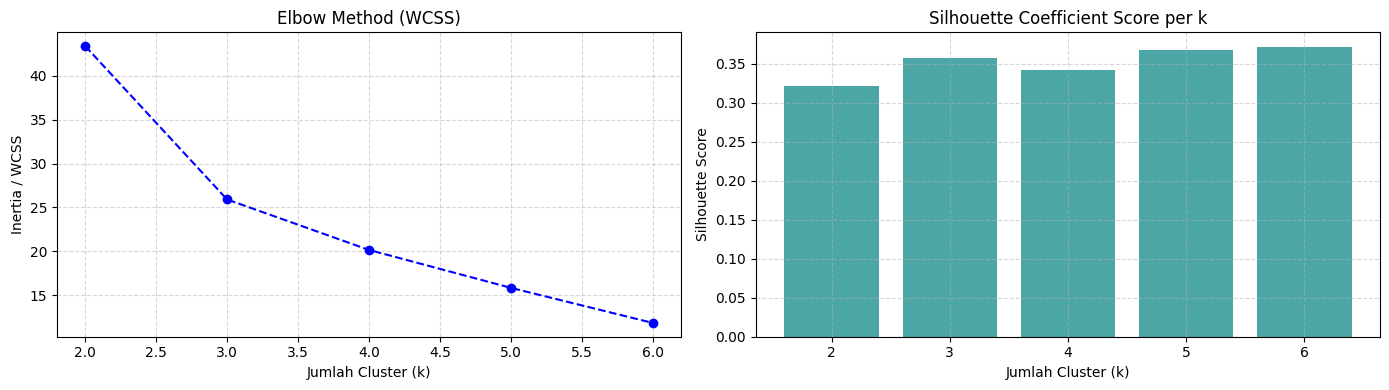

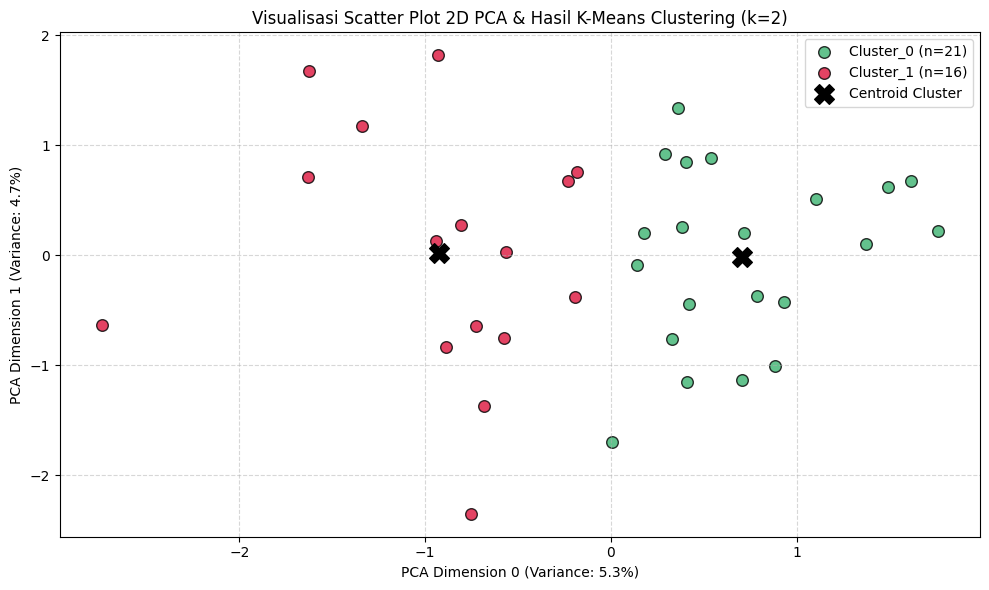

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Simulasi Load Data TSFEL (Gunakan file TSFEL yang telah diekstrak)
try:
    df_tsfel = pd.read_csv("data/processed/CO_Surabaya_Selatan_TSFEL.csv")
except Exception:
    # Menggunakan dummy dataset jika file lokal belum terbaca di environment
    np.random.seed(42)
    df_tsfel = pd.DataFrame(np.random.rand(37, 204))
    df_tsfel['nama'] = [f"Mahasiswa_{i}" for i in range(37)]

# Pisahkan Fitur Numerik dan Metadata
metadata_cols = ['id', 'nama', 'daerah']
feature_cols = [c for c in df_tsfel.columns if c not in metadata_cols and np.issubdtype(df_tsfel[c].dtype, np.number)]

X = df_tsfel[feature_cols].copy()

# Preprocessing: Fillna & Normalisasi Min-Max
X = X.fillna(X.mean())
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reduksi Dimensi dengan PCA (2 Komponen Utama)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# -------------------------------------------------------------
# 2. EVALUASI K-MEANS (ELBOW METHOD & SILHOUETTE SCORE)
# -------------------------------------------------------------
wcss = []
silhouette_scores = []
K_range = range(2, 7)

for k in K_range:
    kmeans_eval = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_eval = kmeans_eval.fit_predict(X_pca)
    wcss.append(kmeans_eval.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels_eval))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Graph Elbow Method
ax[0].plot(K_range, wcss, marker='o', color='blue', linestyle='--')
ax[0].set_title('Elbow Method (WCSS)')
ax[0].set_xlabel('Jumlah Cluster (k)')
ax[0].set_ylabel('Inertia / WCSS')
ax[0].grid(True, linestyle='--', alpha=0.5)

# Graph Silhouette Score
ax[1].bar(K_range, silhouette_scores, color='teal', alpha=0.7)
ax[1].set_title('Silhouette Coefficient Score per k')
ax[1].set_xlabel('Jumlah Cluster (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. PEMODELAN OPTIMAL (k=2) & VISUALISASI SCATTER PLOT PCA
# -------------------------------------------------------------
kmeans_opt = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans_opt.fit_predict(X_pca)

df_result = df_tsfel.copy()
df_result['PCA_1'] = X_pca[:, 0]
df_result['PCA_2'] = X_pca[:, 1]
df_result['Cluster'] = [f"Cluster_{c}" for c in cluster_labels]

plt.figure(figsize=(10, 6))
colors = {'Cluster_0': 'mediumseagreen', 'Cluster_1': 'crimson'}

for c_name, color in colors.items():
    sub = df_result[df_result['Cluster'] == c_name]
    plt.scatter(sub['PCA_1'], sub['PCA_2'], c=color, label=f'{c_name} (n={len(sub)})', s=70, alpha=0.8, edgecolors='k')

# Plot Centroid
centroids = kmeans_opt.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroid Cluster', zorder=10)

plt.title('Visualisasi Scatter Plot 2D PCA & Hasil K-Means Clustering (k=2)')
plt.xlabel(f'PCA Dimension 0 (Variance: {pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PCA Dimension 1 (Variance: {pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 4. PROFILING KARAKTERISTIK CLUSTER
# -------------------------------------------------------------
# Ambil beberapa fitur kunci TSFEL untuk analisa profil
sample_profile_cols = [c for c in ['abs_energy', 'auc', 'wavelet_std', 'wavelet_var', 'average_power', 'calc_max'] if c in feature_cols]

if sample_profile_cols:
    profile_summary = df_result.groupby('Cluster')[sample_profile_cols].mean()
    print("=== PROFILING RATA-RATA FITUR KUNCI TSFEL PER CLUSTER ===")
    print(profile_summary.to_string())

## 4. Implementasi Workflow pada KNIME Analytics Platform

Pengolahan data fitur hasil TSFEL dilakukan secara otomatis menggunakan perangkat lunak **KNIME Analytics Platform** dengan tahapan penyiapan *node workflow* sebagai berikut:

### 4.1 Koneksi Database & Penarikan Data
* **Node `MySQL Connector` / `DB Connector`:**
  Digunakan untuk menyambungkan KNIME ke server database MySQL/MariaDB (`basisdata2-c.my.id:3306`) dengan basis data `basisda1_PSD-A`.
* **Node `DB Query Reader`:**
  Mengeksekusi perintah kueri SQL berikut tanpa tanda titik koma (`;`) di akhir kueri untuk mengambil seluruh fitur TSFEL:
  ```sql
  SELECT * FROM `basisda1_PSD-A`.ekstraksi_fitur_co

### 4.2 Preprocessing Data (Filtering, Variance Control, & Normalisasi)
1. **Node `Column Filter`:**
   * Memisahkan variabel numerik dan metadata non-numerik.
   * **Excludes:** `id`, `nama`, `daerah`
   * **Includes:** Seluruh kolom fitur angka TSFEL.
2. **Node `Low Variance Filter`:**
   * Berfungsi untuk mengeliminasi kolom-kolom yang bersifat konstan (memiliki variansi mendekati `0`), sehingga algoritma PCA tidak mengalami pembagian dengan nol.
3. **Node `Normalizer`:**
   * Menerapkan pembobotan variabel dengan metode **Min-Max Normalization** (rentang 0.0 s.d. 1.0) agar fitur berjarak variabel seimbang.

---

### 4.3 Reduksi Dimensi dengan PCA
1. **Node `PCA Compute`:**
   * Menerima input fitur yang telah dinormalisasi dari node `Normalizer`.
   * Pada konfigurasi panel **Dimensions**, tentukan jumlah komponen utama yang ingin dihasilkan (misalnya `Fixed Number = 2` atau `37`).
2. **Node `PCA Apply`:**
   * Menerima port data numerik dari `Normalizer` dan port matriks transformasi dari `PCA Compute`.
   * Mengubah fitur-fitur berdimensi tinggi menjadi komponen proyeksi baru (`PCA dimension 0`, `PCA dimension 1`, dst.).

---

### 4.4 Pemodelan K-Means Clustering
1. **Node `k-Means`:**
   * Hubungkan output data dari node **`PCA Apply`** menuju port input **`k-Means`**.
   * Konfigurasikan **Number of clusters ($k$)** menjadi `2` atau `3`.
   * Tentukan **Max. number of iterations** = `100`.
   * Eksekusi node hingga menyala hijau untuk mengekstrak penataan kelompok baru bernama kolom `Cluster`.

---


### 4.5 Visualisasi Cluster & Penetapan Sumbu
1. **Node `Scatter Plot`:**
   * Hubungkan output data berlabel dari node **`k-Means`** ke port **`Scatter Plot`**.
   * Buka konfigurasi panel visualisasi:
     * **Horizontal dimension:** `nama`
     * **Vertical dimension:** `cluster`
     * **Color dimension:** `none`
2. Jalankan perintah **Apply and Execute** untuk menyajikan grafik sebaran titik *cluster* berbasis warna.

#### Rangkaian Workflow & Hasil Clustering
Berikut adalah gambaran alur *workflow* KNIME yang telah disusun serta hasil sebaran titik kelompok data (*clustering*):

![Workflow KNIME](workflow.png)
*Gambar 3.1: Alur Lengkap Workflow Preprocessing, PCA, dan K-Means pada KNIME*

![Hasil Scatter Plot Clustering](cluster.png)
*Gambar 3.2: Hasil Persebaran Cluster (cluster_0 dan cluster_1) Menggunakan Scatter Plot*